In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("C:\\Users\\CHIMMULA JOSHIKA\\OneDrive\\Documents\\vscode\\Project1\\HR_Employee_Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


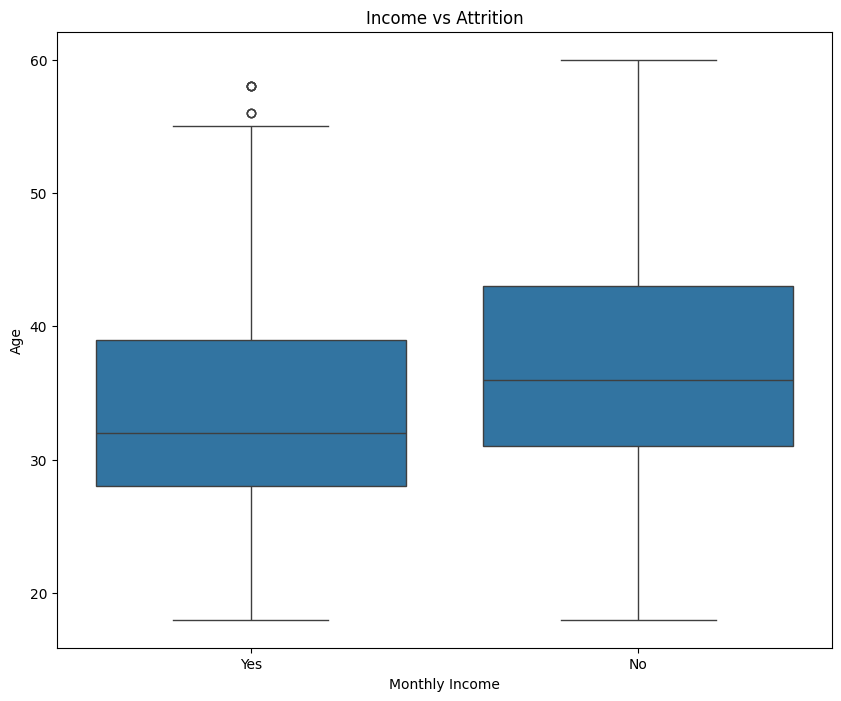

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Montly Income")
plt.show()

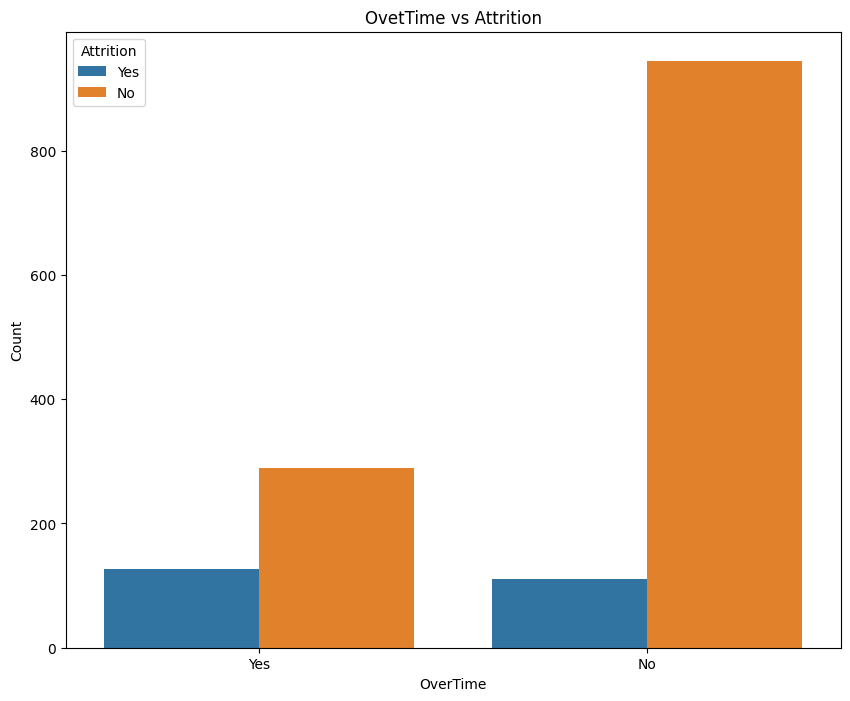

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OvetTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

In [ ]:
# drop irrelevemnt columns
df.drop({"EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"}, axis=1, inplace=True)
#df.info();
#encode categorical variables
encoder={}
for col in df.select_dtypes(include="object").columns:
    lb=LabelEncoder()   
    df[col]=lb.fit_transform(df[col])
    encoder[col]=lb
#split data into features and target
X=df.drop("Attrition", axis=1)
y=df["Attrition"]
#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\CHIMMULA JOSHIKA\AppData\Local\Temp\ipykernel_33820\1147656825.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [ ]:
#define model
rf=RandomForestClassifier(random_state=42)
#Hyperparamter turning
param_grid={
    "n_estimators":[50, 100],   
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
}
grid_search= GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train,y_train)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [ ]:
model=RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(X,y)
#save model
joblib.dump(model, "employee_attrition_model.pkl")  
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")   

['feature_columns.pkl']

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

[[253   2]
 [ 34   5]]


Text(0, 0.5, 'Feature')

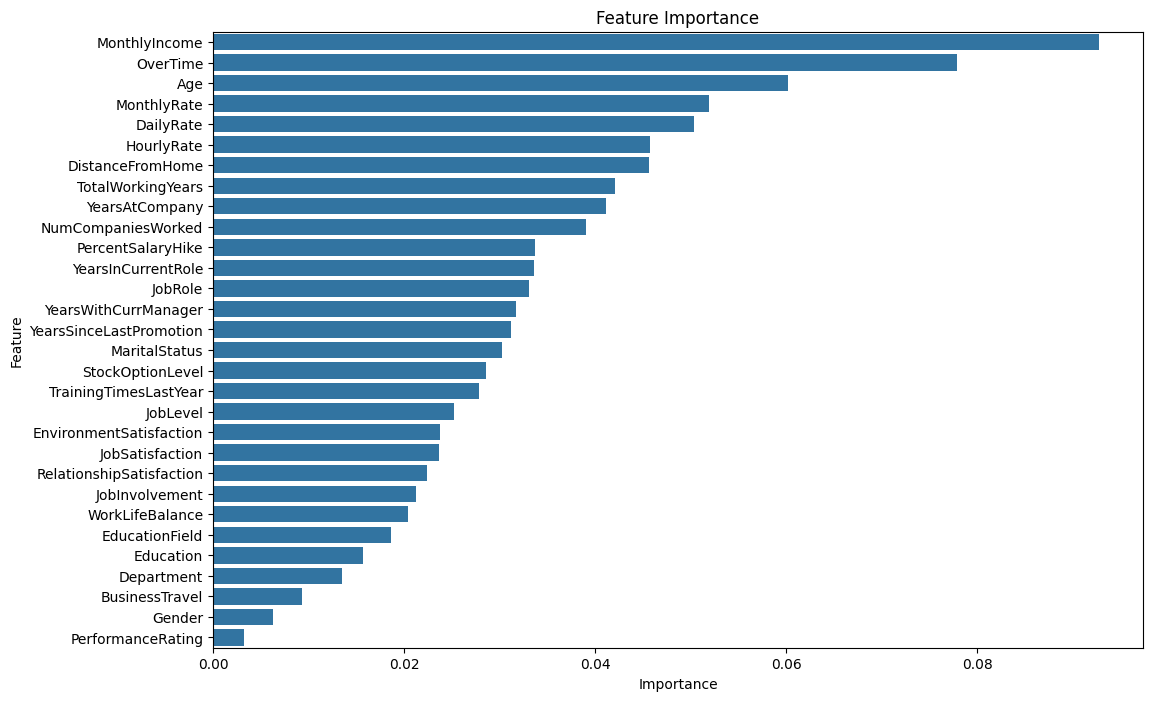

In [ ]:
best_model=grid_search.best_estimator_
predictions=best_model.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))
importances=best_model.feature_importances_
feature_importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(12,8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")